# Ataque Cardiaco con Máquinas de Vectores de Soporte
## Ver 2.0
 En esta versión vamos a incluir las variables dummies asociadas a las variables categóricas.

In [52]:
# Importar las librerias

# Cargamos nuestras librerias
import numpy as np
import pandas as pd

# Entorno SciKit Learn
from sklearn.svm import SVC   # Algoritmo incorpora el truco del Kernel.

from sklearn.model_selection import train_test_split  # Dividir el conjunto de prueba y entrenamiento
from sklearn.model_selection import KFold, RepeatedKFold, cross_val_score # Validación cruzada
from sklearn.model_selection import cross_validate # Validación cruzada
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report
from sklearn.model_selection import KFold, RepeatedKFold
from sklearn.model_selection import GridSearchCV



# Para preprocesamiento
from sklearn.preprocessing import StandardScaler,MinMaxScaler  # La libreria para reescalar datos
import matplotlib.pyplot as plt


In [53]:
# 1. Cargar datos
datos=pd.read_csv("heart_attack.csv")

## Sobre el conjunto de datos

Age : Edad del paciente. (continua)

Sex : Sexo del paciente (0= male; 1 =female)   (categórica)

exang: angina inducida por el ejercicio (1 = yes; 0 = no)  (categórica)

caa: número de vasos principales del corazón (0-4) (Es ordinal, se manejo como continua) 

cp :Tipo de dolor en el pecho    (categórica)

Value 1: typical angina

Value 2: atypical angina

Value 3: non-anginal pain

Value 4: asymptomatic

trtbps : presión arterial en reposo (in mm Hg) (continua)  

chol : cholestoral in mg/dl fetched via BMI sensor  (continua)

fbs : (glucemia en ayunas > 120 mg/dl) (1 = true; 0 = false)  (categórica)

restecg : resultados electrocardiograma en reposo (categórica)

Value 0: normal

Value 1: having ST-T wave abnormality (T wave inversions and/or ST 
elevation or depression of > 0.05 mV)

Value 2: showing probable or definite left ventricular hypertrophy by 
Estes' criteria

thalach :frecuencia cardíaca máxima alcanzada  (continua)

target : 0= less chance of heart attack 1= more chance of heart attack  (categórica)

In [54]:
datos.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,caa,output
0,63,1,3,145,233,1,0,150,0,0,1
1,37,1,2,130,250,0,1,187,0,0,1
2,41,0,1,130,204,0,0,172,0,0,1
3,56,1,1,120,236,0,1,178,0,0,1
4,57,0,0,120,354,0,1,163,1,0,1


In [55]:
# Datos faltantes?
datos.isnull().sum()
#datos.info()

age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
caa         0
output      0
dtype: int64

In [56]:
datos.describe()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,caa,output
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,0.729373,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.022606,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,4.000000,1.000000


In [57]:
datos.output.value_counts(normalize=True)*100

1    54.455446
0    45.544554
Name: output, dtype: float64

El 45.54% de los datos, corresponden a pacientes que tienen pocas probabilidades de sufrir un ataque cardiaco. Mientras que el 54.45% de los pacientes tiene altas probabilidades de sufrir un ataque cardiaco. No observamos desbalanceo en los datos proporcionados.  

{'whiskers': [<matplotlib.lines.Line2D at 0x219612c1550>,
 'caps': [<matplotlib.lines.Line2D at 0x219612c1a90>,
 'boxes': [<matplotlib.lines.Line2D at 0x219612c12b0>],
 'medians': [<matplotlib.lines.Line2D at 0x219612c1fd0>],
 'fliers': [<matplotlib.lines.Line2D at 0x219612fb2b0>],
 'means': []}

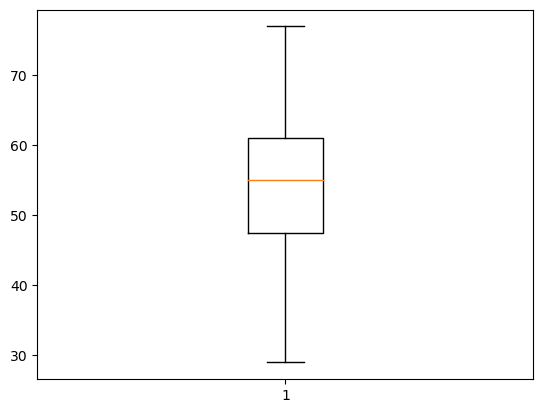

In [58]:
plt.boxplot(datos.age)

{'whiskers': [<matplotlib.lines.Line2D at 0x21961461f10>,
 'caps': [<matplotlib.lines.Line2D at 0x2196146c490>,
 'boxes': [<matplotlib.lines.Line2D at 0x21961461c70>],
 'medians': [<matplotlib.lines.Line2D at 0x2196146c8b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x2196146cb50>],
 'means': []}

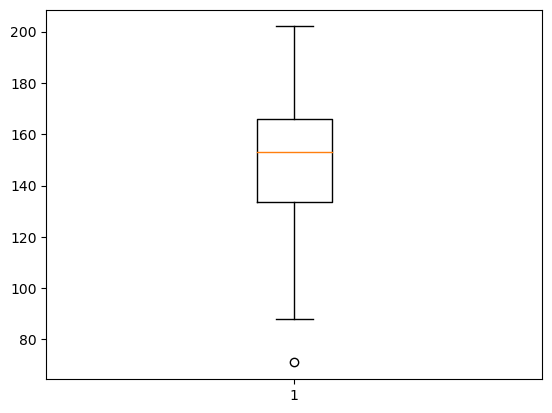

In [59]:
plt.boxplot(datos.thalachh)

{'whiskers': [<matplotlib.lines.Line2D at 0x219614c7430>,
 'caps': [<matplotlib.lines.Line2D at 0x219614c7970>,
 'boxes': [<matplotlib.lines.Line2D at 0x219614c7190>],
 'medians': [<matplotlib.lines.Line2D at 0x219614c7eb0>],
 'fliers': [<matplotlib.lines.Line2D at 0x21961315190>],
 'means': []}

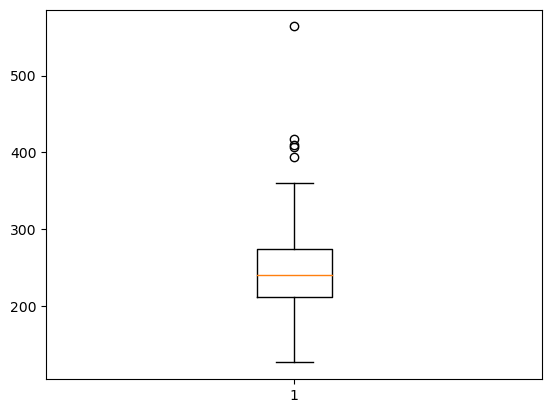

In [60]:
plt.boxplot(datos.chol)

{'whiskers': [<matplotlib.lines.Line2D at 0x21961367340>,
 'caps': [<matplotlib.lines.Line2D at 0x21961367880>,
 'boxes': [<matplotlib.lines.Line2D at 0x219613670a0>],
 'medians': [<matplotlib.lines.Line2D at 0x21961367dc0>],
 'fliers': [<matplotlib.lines.Line2D at 0x219613750a0>],
 'means': []}

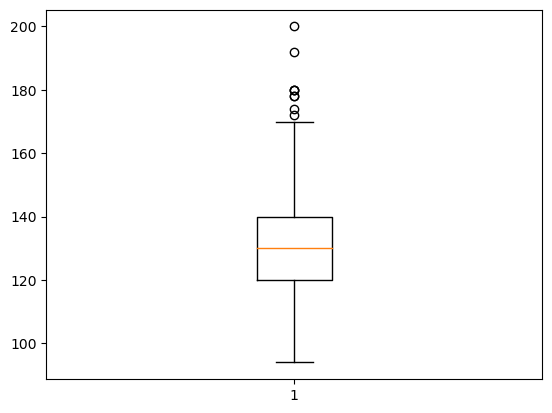

In [61]:
plt.boxplot(datos.trtbps)

Dejamos los outliers, por ahora, y después los vamos a eliminar para medir el efecto que tiene
la presencia de outliers en el desempeño predictivo del modelo.

**Nota 2:** Consideramos ahora a todas las variables.

In [62]:
datos.columns

Index(['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exng', 'caa', 'output'],
      dtype='object')

In [63]:
from sklearn.preprocessing import OneHotEncoder

# Binarizar las categóricas
#binarizar=OneHotEncoder()
#binarizar.fit_transform(datos[["sex","cp","fbs", "restecg",'exng']])
# El resto de variables las tenemos que estandarizar.

# IMPORTANTE: La binarización de los datos y el escalamiento se aprende con
# los datos de entrenamiento.
# Como vamos a hacer una validación cruzada, y no queremos estandarizas las variables binarias
# entonces tenemos que aplicar métodos diferentes a columnas diferentes.

from sklearn.compose import make_column_transformer

colum_transf=make_column_transformer((OneHotEncoder(),["sex","cp","fbs", "restecg",'exng']),
                                     (StandardScaler(),["age",'trtbps','chol', 'thalachh','caa']))


In [64]:
# target
y=datos['output']

del datos["output"]

#Atributos
X=datos


In [47]:
X.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,caa
0,63,1,3,145,233,1,0,150,0,0
1,37,1,2,130,250,0,1,187,0,0
2,41,0,1,130,204,0,0,172,0,0
3,56,1,1,120,236,0,1,178,0,0
4,57,0,0,120,354,0,1,163,1,0


In [65]:
# La métrica depende del conjunto de entrenamiento y prueba, 
# hagamos una validación cruzada para que los resultados no dependan de los conjuntos de 
# entrenamiento.

pipe=make_pipeline(colum_transf, SVC(kernel="linear"))
scores=cross_val_score(pipe,X,y,cv=10, scoring="accuracy", n_jobs=-1)
print("La exactitud promedio es: {:.3f} +/- {:.3f}". format(scores.mean(), scores.std()))



La exactitud promedio es: 0.792 +/- 0.050


In [ ]:
# Mejoramos la exactitud del modelo... 

In [67]:
modelo_final=SVC(kernel="linear")
# Este modelo lo vamos entrenar empleando TODOS los datos, OJO: Escalar los datos y aplicar 
# OneHotEncoder 
X_std= colum_transf.fit_transform(X)  #>-Todos los datos reescalados.

# Con TODOS los datos reescalados, entrenamos el modelo final
modelo_final.fit(X_std, y)

SVC(kernel='linear')

In [69]:
X.columns

Index(['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exng', 'caa'],
      dtype='object')

In [72]:
# Hacer predicciones.
datos_nuevos=pd.DataFrame({"age":[55,60],"sex":[0,1],"cp":[1,2],"trtbps":[140,150],
                           "chol":[220,180],"fbs":[1,1],'restecg':[1,2],
                           "thalachh":[110,118],'exng':[1,0],"caa":[3,4]})
datos_nuevos


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,caa
0,55,0,1,140,220,1,1,110,1,3
1,60,1,2,150,180,1,2,118,0,4


In [73]:
# Primero estandarizamos
datos_nuevos_std=colum_transf.transform(datos_nuevos)
datos_nuevos_std

array([[ 1.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  1.        ,  0.06988599,  0.47839125,
        -0.50756498, -1.73377741,  2.22410436],
       [ 0.        ,  1.        ,  0.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         1.        ,  1.        ,  0.        ,  0.62133012,  1.04952029,
        -1.28058427, -1.38393337,  3.20361543]])

In [74]:
modelo_final.predict(datos_nuevos_std)

array([0, 0], dtype=int64)

In [75]:
# Estos resultados tienen una exactitud del 0.792 +/- 0.050

In [ ]:
# Y la regularización del parámetro C=? y el Kernel=?
# Y los valores atípicos? 
